In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [49]:
df = pd.read_csv("data/player_data_COMPLETE.csv")

Filtramos para que nos salgan únicamente los jugadores de la posición que queremos

In [50]:
df_mf_todos = df[df["main_position"].isin(["AM"])].copy()
df_clustering = df_mf_todos[df_mf_todos["low_minutes_flag"] == False].copy()

Selección de métricas

In [51]:
features_clustering = [
    
    # pase / control
    "passes_avg",
    "progressive_pass_avg",
    
    # creación
    "xg_assist_avg",
    "goals_avg",
    
    # progresión
    "real_progression",
    "dribble_efficiency", 
    
    # defensa
    "interceptions_avg",
    "successful_defensive_actions_avg"

]

X = df_clustering[features_clustering].fillna(0)

Escalado

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [53]:
df_scaled = pd.DataFrame(X_scaled, columns=features_clustering)
print("\nDatos estandarizados:")
print(df_scaled.head())


Datos estandarizados:
   passes_avg  progressive_pass_avg  xg_assist_avg  goals_avg  \
0   -1.782341             -1.681297       0.047070   0.005925   
1   -1.718111             -1.480060      -1.148671  -0.799970   
2   -1.253078             -1.637804      -1.456261  -1.245790   
3   -0.693274             -1.164573      -0.379695   2.575525   
4   -0.418883             -0.321253      -0.072104  -0.354150   

   real_progression  dribble_efficiency  interceptions_avg  \
0         -1.693408           -0.485360          -0.181623   
1         -1.560183           -0.566931          -1.286478   
2         -0.635764            1.008147          -0.161374   
3         -0.569734            1.100769           0.432781   
4         -0.524021            0.786934          -0.363640   

   successful_defensive_actions_avg  
0                          0.188568  
1                         -1.255319  
2                          0.293214  
3                          0.413879  
4                      

PCA: Reducción de dimensionalidad

In [54]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.37343227 0.27873291 0.11818487]


In [55]:
n_components = 3
pca_clustering = pd.DataFrame(data=X_pca, columns=[f'PC{i}' for i in range(1, n_components+1)])
print("\nComponentes principales:")
print(pca_clustering.head())


Componentes principales:
        PC1       PC2       PC3
0 -2.754380 -0.175808  0.093243
1 -3.171735 -1.059903 -0.248135
2 -2.224191  0.401960  1.727418
3 -1.082701 -0.808768  1.259434
4 -0.553792  0.162447  0.947790


C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the

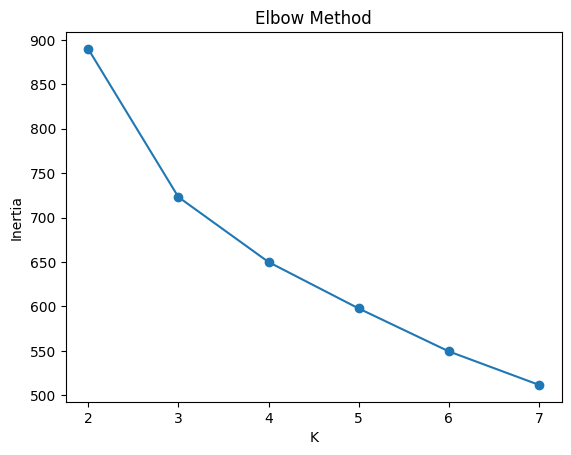

In [56]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [57]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_clustering["cb_cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [58]:
cluster_profile = df_clustering.groupby("cb_cluster")[features_clustering].mean()
print(cluster_profile)

            passes_avg  progressive_pass_avg  xg_assist_avg  goals_avg  \
cb_cluster                                                               
0            36.190209              5.101576       0.108371   0.133106   
1            36.290828              4.640622       0.156748   0.307421   
2            42.341480              7.165454       0.204230   0.179359   
3            24.525812              2.929575       0.080957   0.169732   

            real_progression  dribble_efficiency  interceptions_avg  \
cb_cluster                                                            
0                   6.478315            0.954134           3.011998   
1                   6.738137            1.464265           1.721659   
2                   9.718433            2.131594           2.055792   
3                   4.360957            1.122536           1.838566   

            successful_defensive_actions_avg  
cb_cluster                                    
0                                 

In [59]:
cols_show = ["name", "market_value", "minutes_on_field", "cb_cluster"]

df_cb_view = df_clustering[cols_show].sort_values(
    ["cb_cluster", "market_value"],
    ascending=[True, False]
)

for c in sorted(df_clustering["cb_cluster"].unique()):
    print(f"\n--- CLUSTER {c} ---")
    display(df_cb_view[df_cb_view["cb_cluster"] == c].head(10))


--- CLUSTER 0 ---


,name,market_value,minutes_on_field,cb_cluster
1150,J. Bellingham,180000000.0,2581,0
2333,A. Rabiot,35000000.0,3248,0
2920,M. Mount,35000000.0,981,0
1546,Yéremy Pino,30000000.0,2547,0
3413,K. Dewsbury-Hall,30000000.0,1317,0
3489,W. McKennie,28000000.0,2778,0
2312,F. Aursnes,20000000.0,1704,0
3071,Carlos Soler,20000000.0,1981,0
3779,G. Reyna,18000000.0,604,0
1231,C. Chukwuemeka,15000000.0,706,0



--- CLUSTER 1 ---


,name,market_value,minutes_on_field,cb_cluster
1487,J. Musiala,130000000.0,1823,1
1033,X. Simons,80000000.0,2371,1
1613,C. Palmer,80000000.0,2614,1
3007,Dani Olmo,60000000.0,1657,1
669,A. Garnacho,45000000.0,2019,1
2251,S. Gnabry,40000000.0,1383,1
2321,J. Brandt,40000000.0,2021,1
1454,T. Almada,27000000.0,1382,1
2784,L. Pellegrini,25000000.0,1298,1
3426,A. Gomes,25000000.0,1058,1



--- CLUSTER 2 ---


,name,market_value,minutes_on_field,cb_cluster
1880,K. De Bruyne,50000000.0,2350,2
963,H. Elliott,35000000.0,579,2
1413,R. Cherki,25000000.0,2147,2
1672,L. Samardžić,20000000.0,1369,2
2981,G. Lo Celso,16000000.0,1947,2
1482,Rodrigo Zalazar,12000000.0,1501,2
1729,M. Damsgaard,10000000.0,3129,2
1940,Isco,8000000.0,1746,2
2836,F. Neuhaus,7000000.0,884,2
1862,S. El Shaarawy,5000000.0,959,2



--- CLUSTER 3 ---


,name,market_value,minutes_on_field,cb_cluster
3904,Oihan Sancet,35000000.0,1762,3
2360,A. Gudmundsson,30000000.0,1792,3
3493,João Félix,30000000.0,1123,3
1393,Ansu Fati,25000000.0,576,3
2915,N. Tella,23000000.0,1554,3
2777,E. Buendía,22000000.0,949,3
3409,E. Smith Rowe,22000000.0,1685,3
2176,T. Minamino,20000000.0,2355,3
775,H. Diarra,18000000.0,1937,3
1439,G. Rutter,18000000.0,1975,3


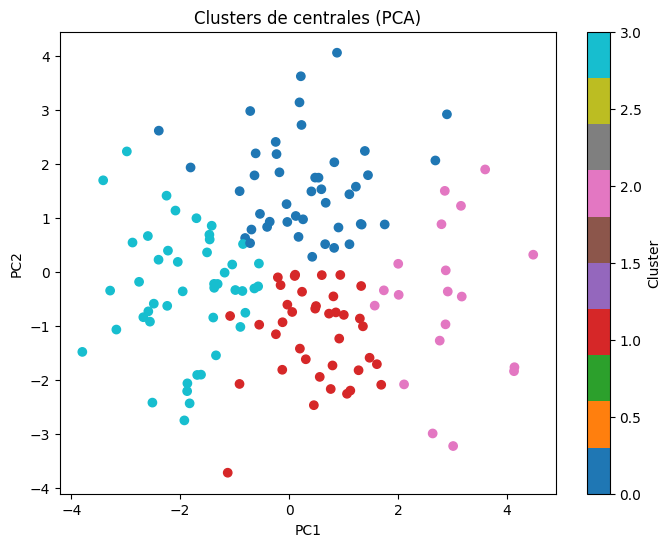

In [60]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_clustering["cb_cluster"],
    cmap="tab10"
)

plt.title("Clusters de centrales (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Cluster")
plt.show()

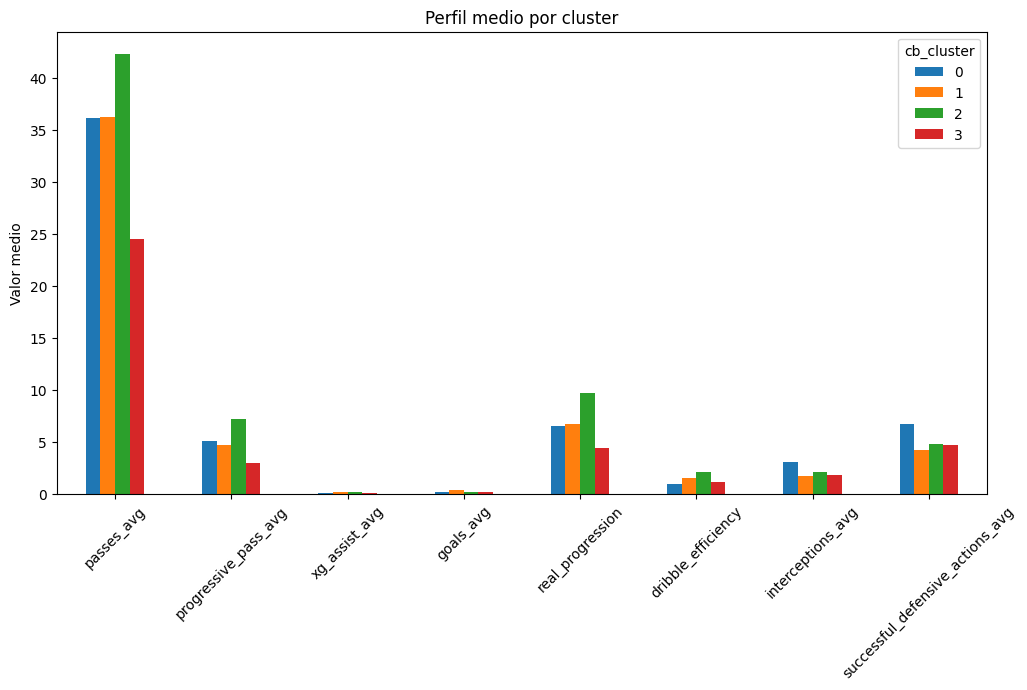

In [61]:
cluster_profile.T.plot(kind="bar", figsize=(12,6))
plt.title("Perfil medio por cluster")
plt.xticks(rotation=45)
plt.ylabel("Valor medio")
plt.show()

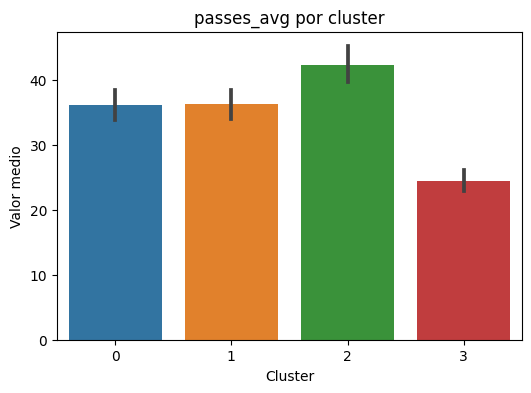

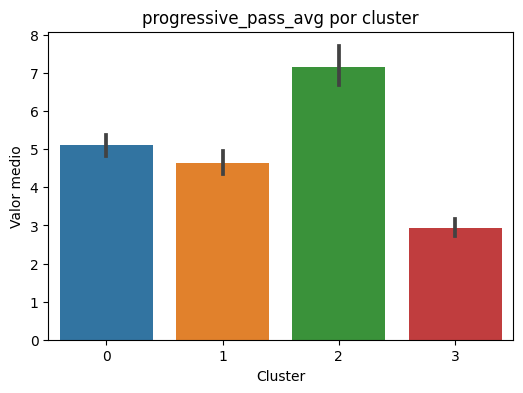

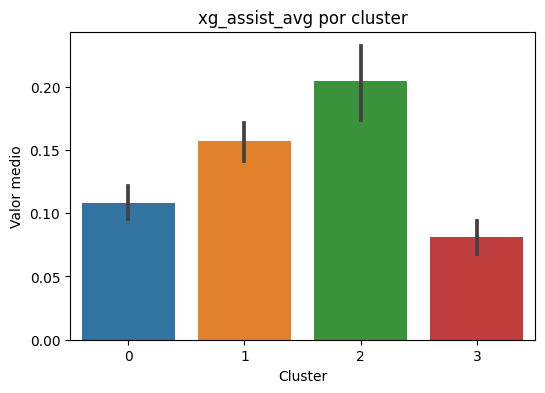

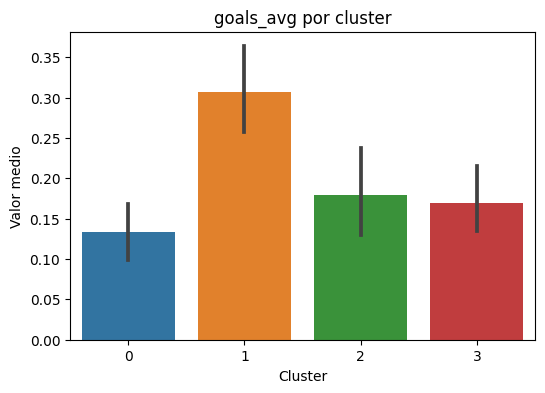

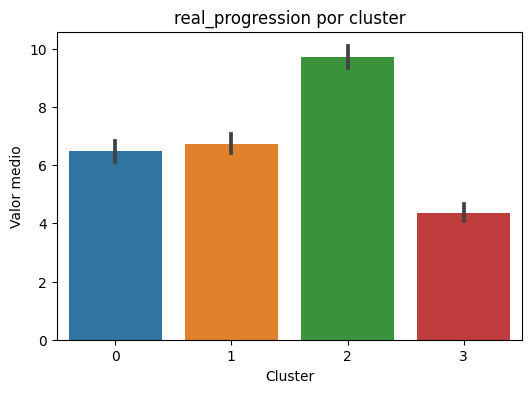

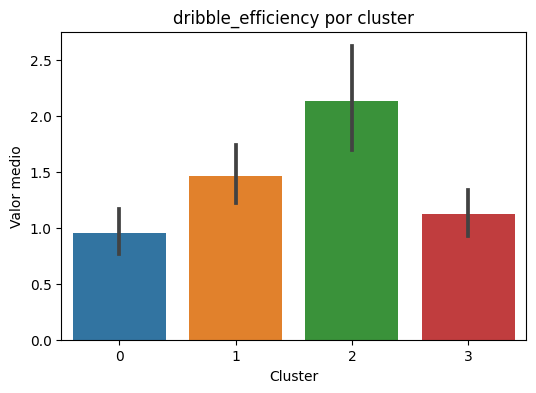

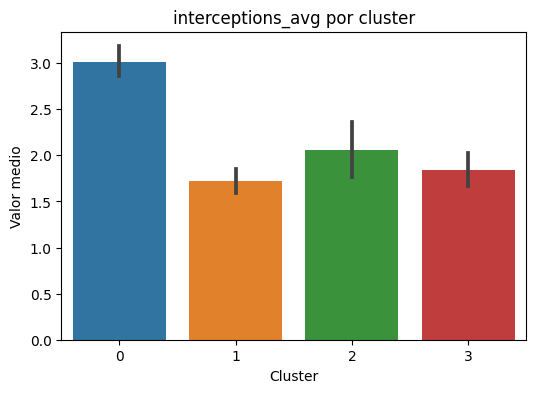

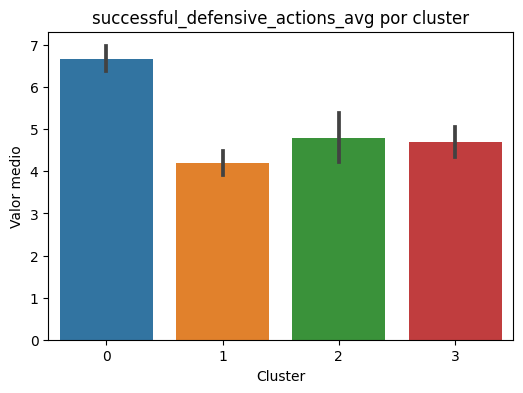

In [62]:
for col in features_clustering:
    
    plt.figure(figsize=(6,4))
    
    sns.barplot(
        x="cb_cluster",
        y=col,
        data=df_clustering
    )
    
    plt.title(f"{col} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Valor medio")
    
    plt.show()

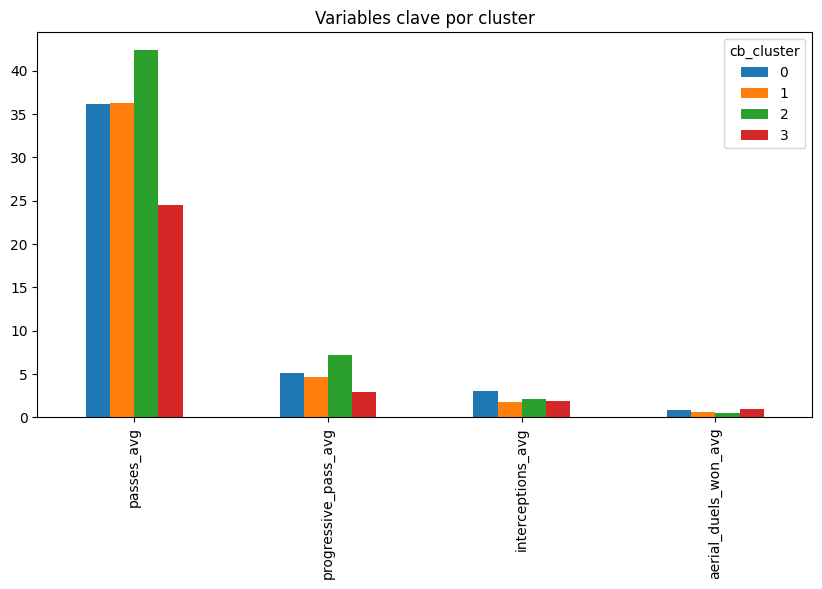

In [63]:
key_vars = [
    "passes_avg",
    "progressive_pass_avg",
    "interceptions_avg",
    "aerial_duels_won_avg"
]

df_clustering.groupby("cb_cluster")[key_vars].mean().T.plot(kind="bar", figsize=(10,5))
plt.title("Variables clave por cluster")
plt.show()

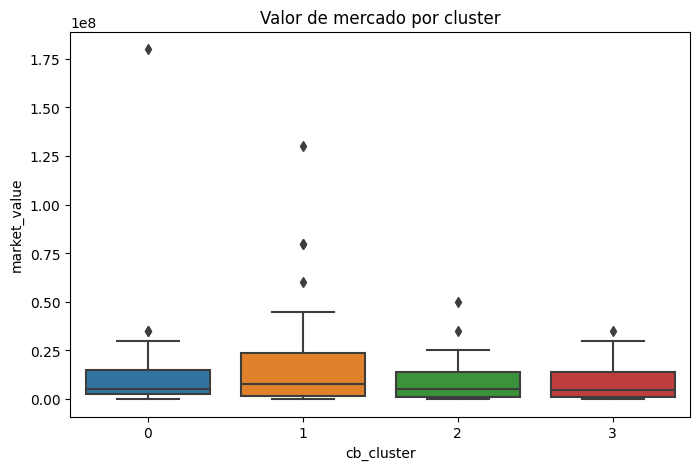

In [64]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cb_cluster", y="market_value", data=df_clustering)
plt.title("Valor de mercado por cluster")
plt.show()

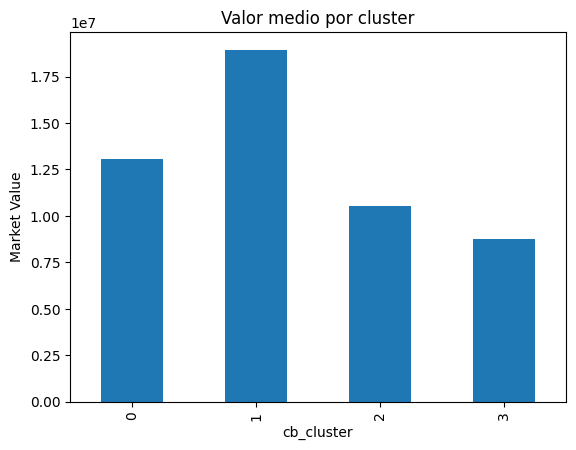

In [65]:
df_clustering.groupby("cb_cluster")["market_value"].mean().plot(kind="bar")

plt.title("Valor medio por cluster")
plt.ylabel("Market Value")
plt.show()

In [66]:
loadings = pd.DataFrame(
    pca.components_,
    columns=features_clustering,
    index=["PC1", "PC2", "PC3"]
)

display(loadings)

,passes_avg,progressive_pass_avg,xg_assist_avg,goals_avg,real_progression,dribble_efficiency,interceptions_avg,successful_defensive_actions_avg
PC1,0.478667,0.531923,0.382427,0.027234,0.545854,0.187931,0.082579,0.029133
PC2,0.072657,0.113560,-0.247478,-0.377372,-0.020898,-0.243062,0.596785,0.602082
PC3,-0.281585,-0.164230,-0.116514,-0.077793,0.156918,0.888605,0.120718,0.212829


cluster_labels = {
    0: "Attacking midfielder",
    1: "Low-impact midfielder",
    2: "Deep-lying playmaker midfielder",
    3: "Ball-winning midfielder"
}


In [67]:
cb_labels = {
    0: "Ball-stealing CB",
    1: "Ball-playing CB",
    2: "Aerial dominant CB",
    3: "Low-impact CB"
}

fb_labels = {
    0: "Attacking full-back",
    1: "Creative full-back",
    2: "Low-impact full-back",
    3: "Defensive full-back"
}

mf_labels = {
    0: "Attacking midfielder",
    1: "Low-impact midfielder",
    2: "Deep-lying playmaker",
    3: "Ball-winning midfielder"
}

am_labels = {
    0: "Box-to-box attacking midfielder",
    1: "Goal-scoring attacking midfielder",
    2: "Offensive playmaker",
    3: "Low-impact attacking midfielder"
}

w_labels = {
    0: "Dribbler winger",
    1: "Low-impact winger",
    2: "Defensive winger",
    3: "Goal-scoring winger"
}

fw_labels = {
    0: "Target man",
    1: "Pressing forward",
    2: "Creative forward",
    3: "Poacher"
}

gk_labels = {
    0: "Low-performing GK",
    1: "Shot-stopper GK",
    2: "Ball-playing GK",
    3: "Low-impact GK"
}

def assign_role(row):
  
    return am_labels.get(row["cb_cluster"])


df_clustering["player_role"] = df_clustering.apply(assign_role, axis=1)

In [68]:
df_clustering[["id", "name", "cb_cluster", "player_role"]].to_csv("clustering/data/am_clusters.csv", index=False)